# Mataquito River – Quartz & Zircon Fertility Analysis
Monte Carlo error propagation using flux-ordered erosion rates and detritalPy-mix bootstrap coefficients.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import os

os.makedirs('Figures', exist_ok=True)
np.random.seed(17)
N = 100_000  # Monte Carlo sample size

## 2. Load sample data

In [2]:
df = pd.read_excel('/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx')
# Index: CT-1=0, CT-2=1, CT-3=2, CT-4=3, CT-5=4, CT-6=5, CT-7=6, CT-8=7, CT-9=8, CT-10=9, CT-11=10
print(df[['Sample_ID','Source_Area','Erosion_rate',
          'Erosion_rate_uncertainty_internal',
          'Erosion_rate_uncertainty_external',
          'Surface_Production_Rate']])

   Sample_ID  Source_Area  Erosion_rate  Erosion_rate_uncertainty_internal  \
0       CT-1     1385.185          22.9                              0.281   
1       CT-2     5760.128          94.8                              1.810   
2       CT-3      189.205          29.5                              0.556   
3       CT-4     4706.717          29.6                              0.594   
4       CT-5     1495.897         387.0                              9.230   
5       CT-6     2573.245          29.8                              0.566   
6       CT-7     1207.810         532.0                             30.600   
7       CT-8     4950.395         263.0                              9.650   
8       CT-9     6189.716         105.0                              2.010   
9      CT-10     4864.942         246.0                              8.660   
10     CT-11     4913.334         286.0                              9.560   

    Erosion_rate_uncertainty_external  Surface_Production_Rate 

## 3. Monte Carlo erosion rate samples
Two sets: one using **internal** uncertainty (analytical only), one using **external** uncertainty (includes production rate uncertainty).  
External is more conservative and is used as the default for fertility calculations.

In [3]:
np.random.seed(17)
ER_int = {}  # internal uncertainty
ER_ext = {}  # external uncertainty

for i, row in df.iterrows():
    sid = row['Sample_ID']
    ER_int[sid] = np.random.normal(row['Erosion_rate'], row['Erosion_rate_uncertainty_internal'], N)
    ER_ext[sid] = np.random.normal(row['Erosion_rate'], row['Erosion_rate_uncertainty_external'], N)

print("Sample      Median_int  Std_int   Median_ext  Std_ext")
for sid in df['Sample_ID']:
    print(f"{sid:<10}  {np.median(ER_int[sid]):8.3f}  {np.std(ER_int[sid]):7.3f}   {np.median(ER_ext[sid]):8.3f}  {np.std(ER_ext[sid]):7.3f}")

Sample      Median_int  Std_int   Median_ext  Std_ext
CT-1          22.900    0.281     22.906    1.857
CT-2          94.801    1.805     94.828    7.729
CT-3          29.500    0.554     29.497    2.418
CT-4          29.601    0.593     29.593    2.435
CT-5         386.999    9.238    386.762   32.015
CT-6          29.801    0.568     29.794    2.443
CT-7         532.114   30.685    531.662   52.232
CT-8         262.999    9.661    262.953   22.892
CT-9         104.992    2.007    105.060    8.542
CT-10        245.998    8.667    246.075   21.398
CT-11        285.993    9.587    286.173   24.513


## 4. Flux ordering
Enforce physical constraint: downstream flux ≥ upstream flux (E×A).  
Pairs: CT-7→CT-5, CT-1→CT-6, then combined CT-5+CT-6→CT-4/CT-10/CT-11/CT-8, CT-4→CT-8 (for CT-8.2 parent set).

In [4]:
def flux_order_1to1(er_up, er_down, A_up, A_down, er_samples):
    """Return mask where downstream flux >= upstream flux."""
    return np.where(er_down * A_down >= er_up * A_up)[0]

def flux_order_2to1(er_a, er_b, er_c, A_a, A_b, A_c, er_samples_a, er_samples_b, er_samples_c):
    """Return mask where child flux >= combined parent flux."""
    return np.where(er_c * A_c >= er_a * A_a + er_b * A_b)[0]

np.random.seed(17)

A = df.set_index('Sample_ID')['Source_Area'].to_dict()

# CT-7 → CT-5 (flux order CT-5 relative to CT-7)
mask_75 = flux_order_1to1(ER_ext['CT-7'], ER_ext['CT-5'], A['CT-7'], A['CT-5'], None)
CT5_ord = ER_ext['CT-5'][mask_75]
CT7_ord = ER_ext['CT-7'][mask_75]
print(f"CT-7→CT-5: {len(mask_75)}/{N} retained ({100*len(mask_75)/N:.1f}%)")

# CT-1 → CT-6
mask_16 = flux_order_1to1(ER_ext['CT-1'], ER_ext['CT-6'], A['CT-1'], A['CT-6'], None)
CT6_ord = ER_ext['CT-6'][mask_16]
CT1_ord = ER_ext['CT-1'][mask_16]
print(f"CT-1→CT-6: {len(mask_16)}/{N} retained ({100*len(mask_16)/N:.1f}%)")

# Resample CT-5 and CT-6 to N for downstream use
CT5_res = np.random.choice(CT5_ord, size=N, replace=True)
CT6_res = np.random.choice(CT6_ord, size=N, replace=True)

# CT-5+CT-6 → CT-10
mask_5610 = flux_order_2to1(CT5_res, CT6_res, ER_ext['CT-10'], A['CT-5'], A['CT-6'], A['CT-10'], None, None, None)
CT5_10 = CT5_res[mask_5610];  CT6_10 = CT6_res[mask_5610];  CT10_f = ER_ext['CT-10'][mask_5610]
print(f"CT-5+CT-6→CT-10: {len(mask_5610)}/{N} retained ({100*len(mask_5610)/N:.1f}%)")

# CT-5+CT-6 → CT-11
mask_5611 = flux_order_2to1(CT5_res, CT6_res, ER_ext['CT-11'], A['CT-5'], A['CT-6'], A['CT-11'], None, None, None)
CT5_11 = CT5_res[mask_5611];  CT6_11 = CT6_res[mask_5611];  CT11_f = ER_ext['CT-11'][mask_5611]
print(f"CT-5+CT-6→CT-11: {len(mask_5611)}/{N} retained ({100*len(mask_5611)/N:.1f}%)")

# CT-5+CT-6 → CT-8
mask_568 = flux_order_2to1(CT5_res, CT6_res, ER_ext['CT-8'], A['CT-5'], A['CT-6'], A['CT-8'], None, None, None)
CT5_8  = CT5_res[mask_568];   CT6_8  = CT6_res[mask_568];   CT8_f  = ER_ext['CT-8'][mask_568]
print(f"CT-5+CT-6→CT-8:  {len(mask_568)}/{N} retained ({100*len(mask_568)/N:.1f}%)")

# CT-4 → CT-8 (for CT-8.2 parent set; CT-8 must have more flux than CT-4)
mask_48 = flux_order_1to1(ER_ext['CT-4'], ER_ext['CT-8'], A['CT-4'], A['CT-8'], None)
CT8_48 = ER_ext['CT-8'][mask_48]
CT8_res = np.random.choice(CT8_48, size=N, replace=True)  # resampled CT-8 for CT-8.2 scenarios
CT3_res = np.random.choice(ER_ext['CT-3'], size=N, replace=True)  # CT-3 independent
print(f"CT-4→CT-8:       {len(mask_48)}/{N} retained ({100*len(mask_48)/N:.1f}%)")

print()
print("Flux-ordered median erosion rates (external uncertainty):")
for label, arr in [('CT-5 (for CT-10/11/8)', CT5_res), ('CT-6 (for CT-10/11/8)', CT6_res),
                   ('CT-8 (for CT-9/CT-2)',  CT8_res),  ('CT-3 (independent)',    CT3_res),
                   ('CT-10',CT10_f),('CT-11',CT11_f),('CT-8 (via CT-5+CT-6)',CT8_f)]:
    print(f"  {label:<28}: {np.median(arr):.2f} ± {np.std(arr):.2f}")

CT-7→CT-5: 21127/100000 retained (21.1%)
CT-1→CT-6: 100000/100000 retained (100.0%)
CT-5+CT-6→CT-10: 99999/100000 retained (100.0%)
CT-5+CT-6→CT-11: 100000/100000 retained (100.0%)
CT-5+CT-6→CT-8:  100000/100000 retained (100.0%)
CT-4→CT-8:       100000/100000 retained (100.0%)

Flux-ordered median erosion rates (external uncertainty):
  CT-5 (for CT-10/11/8)       : 413.24 ± 27.24
  CT-6 (for CT-10/11/8)       : 29.79 ± 2.45
  CT-8 (for CT-9/CT-2)        : 262.92 ± 22.76
  CT-3 (independent)          : 29.50 ± 2.42
  CT-10                       : 246.08 ± 21.40
  CT-11                       : 286.17 ± 24.51
  CT-8 (via CT-5+CT-6)        : 262.95 ± 22.89


## 5. Quartz fertility
**Equation:** Q_b/Q_a = (P_c·E_a·A_a − P_a·E_c·A_c) / (P_b·E_c·A_b − P_c·E_b·A_b)

where a=CT-5, b=CT-6, c=child sample.  
Only positive Q values are retained (negative values indicate the equation is not constrained for that sample combination).

In [5]:
def quartz_fertility(E_a, E_b, E_c, A_a, A_b, A_c, P_a, P_b, P_c):
    """
    Returns Qb/Qa and Qa/Qb arrays. Only positive samples retained.
    Equation: Qb/Qa = (Pc*Ea*Aa - Pa*Ec*Aa) / (Pb*Ec*Ab - Pc*Eb*Ab)
    """
    num = P_c * E_a * A_a - P_a * E_c * A_a
    den = P_b * E_c * A_b - P_c * E_b * A_b
    Q = num / den
    mask = Q > 0
    return Q[mask], (1/Q)[mask], mask

P = df.set_index('Sample_ID')['Surface_Production_Rate'].to_dict()

# CT-5+CT-6 → CT-4 (uses unordered samples — CT-4 is not flux-ordered above CT-5+CT-6)
Q_ct4, Qi_ct4, _ = quartz_fertility(ER_ext['CT-5'], ER_ext['CT-6'], ER_ext['CT-4'],
                                     A['CT-5'], A['CT-6'], A['CT-4'],
                                     P['CT-5'], P['CT-6'], P['CT-4'])

# CT-5+CT-6 → CT-10
Q_ct10, Qi_ct10, _ = quartz_fertility(CT5_10, CT6_10, CT10_f,
                                       A['CT-5'], A['CT-6'], A['CT-10'],
                                       P['CT-5'], P['CT-6'], P['CT-10'])

# CT-5+CT-6 → CT-11
Q_ct11, Qi_ct11, _ = quartz_fertility(CT5_11, CT6_11, CT11_f,
                                       A['CT-5'], A['CT-6'], A['CT-11'],
                                       P['CT-5'], P['CT-6'], P['CT-11'])

# CT-5+CT-6 → CT-8.2
Q_ct82, Qi_ct82, _ = quartz_fertility(CT5_8, CT6_8, CT8_f,
                                       A['CT-5'], A['CT-6'], A['CT-8'],
                                       P['CT-5'], P['CT-6'], P['CT-8'])

# CT-8.2+CT-3 → CT-9  (A_CT3 adjusted = CT-9 - CT-8)
A_CT3_9 = A['CT-9'] - A['CT-8']
Q_ct9, Qi_ct9, _ = quartz_fertility(CT8_res, CT3_res, ER_ext['CT-9'],
                                     A['CT-8'], A_CT3_9, A['CT-9'],
                                     P['CT-8'], P['CT-3'], P['CT-9'])

# CT-8.2+CT-3 → CT-2  (A_CT3 adjusted = CT-2 - CT-8)
A_CT3_2 = A['CT-2'] - A['CT-8']
Q_ct2, Qi_ct2, _ = quartz_fertility(CT8_res, CT3_res, ER_ext['CT-2'],
                                     A['CT-8'], A_CT3_2, A['CT-2'],
                                     P['CT-8'], P['CT-3'], P['CT-2'])

print("Quartz Fertility Results (Qb/Qa, external uncertainty)")
print(f"{'Scenario':<25} {'Qb/Qa median':>12} {'25th':>8} {'75th':>8} {'n':>7}")
print("-"*65)
for label, Q in [('CT-6/CT-5 → CT-4',   Q_ct4),
                 ('CT-6/CT-5 → CT-10',  Q_ct10),
                 ('CT-6/CT-5 → CT-11',  Q_ct11),
                 ('CT-6/CT-5 → CT-8.2', Q_ct82),
                 ('CT-3/CT-8 → CT-9',   Q_ct9),
                 ('CT-3/CT-8 → CT-2',   Q_ct2)]:
    q25, q50, q75 = np.percentile(Q, [25, 50, 75])
    print(f"{label:<25} {q50:>12.4f} {q25:>8.4f} {q75:>8.4f} {len(Q):>7}")

Quartz Fertility Results (Qb/Qa, external uncertainty)
Scenario                  Qb/Qa median     25th     75th       n
-----------------------------------------------------------------
CT-6/CT-5 → CT-4               79.4855  46.9857 164.6469   55621
CT-6/CT-5 → CT-10               0.2851   0.2071   0.3725   99757
CT-6/CT-5 → CT-11               0.1335   0.0761   0.2019   90918
CT-6/CT-5 → CT-8.2              0.2069   0.1370   0.2865   98307
CT-3/CT-8 → CT-9               33.8803  26.6361  43.9035   99990
CT-3/CT-8 → CT-2               90.7808  68.6829 126.6650   99523


## 6. Quartz fertility: internal vs external uncertainty comparison

In [6]:
# Rerun key scenarios with internal uncertainty for comparison
# CT-5+CT-6 → CT-10 (flux ordering redone with internal ER)
np.random.seed(17)
CT5_res_i = np.random.choice(ER_int['CT-5'][np.where(ER_int['CT-5']*A['CT-5'] > ER_int['CT-7']*A['CT-7'])[0]], size=N, replace=True)
CT6_res_i = np.random.choice(ER_int['CT-6'][np.where(ER_int['CT-6']*A['CT-6'] > ER_int['CT-1']*A['CT-1'])[0]], size=N, replace=True)

mask_i_10 = np.where(ER_int['CT-10']*A['CT-10'] >= CT5_res_i*A['CT-5'] + CT6_res_i*A['CT-6'])[0]
Q_ct10_i, _, _ = quartz_fertility(CT5_res_i[mask_i_10], CT6_res_i[mask_i_10], ER_int['CT-10'][mask_i_10],
                                   A['CT-5'], A['CT-6'], A['CT-10'], P['CT-5'], P['CT-6'], P['CT-10'])

mask_i_8 = np.where(ER_int['CT-8']*A['CT-8'] >= CT5_res_i*A['CT-5'] + CT6_res_i*A['CT-6'])[0]
Q_ct82_i, _, _ = quartz_fertility(CT5_res_i[mask_i_8], CT6_res_i[mask_i_8], ER_int['CT-8'][mask_i_8],
                                   A['CT-5'], A['CT-6'], A['CT-8'], P['CT-5'], P['CT-6'], P['CT-8'])

CT8_res_i = np.random.choice(ER_int['CT-8'][np.where(ER_int['CT-8']*A['CT-8'] > ER_int['CT-4']*A['CT-4'])[0]], size=N, replace=True)
CT3_res_i = np.random.choice(ER_int['CT-3'], size=N, replace=True)
Q_ct9_i, _, _ = quartz_fertility(CT8_res_i, CT3_res_i, ER_int['CT-9'],
                                  A['CT-8'], A_CT3_9, A['CT-9'], P['CT-8'], P['CT-3'], P['CT-9'])

print("Quartz fertility: internal vs external uncertainty (median, IQR)")
print(f"{'Scenario':<22} {'Internal':>20} {'External':>20}")
print("-"*65)
for label, Qi, Qe in [('CT-6/CT-5→CT-10', Q_ct10_i, Q_ct10),
                       ('CT-6/CT-5→CT-8.2', Q_ct82_i, Q_ct82),
                       ('CT-3/CT-8→CT-9',   Q_ct9_i,  Q_ct9)]:
    qi25,qi50,qi75 = np.percentile(Qi,[25,50,75])
    qe25,qe50,qe75 = np.percentile(Qe,[25,50,75])
    print(f"{label:<22} {qi50:6.3f} ({qi25:.3f}-{qi75:.3f})   {qe50:6.3f} ({qe25:.3f}-{qe75:.3f})")

Quartz fertility: internal vs external uncertainty (median, IQR)
Scenario                           Internal             External
-----------------------------------------------------------------
CT-6/CT-5→CT-10         0.232 (0.203-0.263)    0.285 (0.207-0.372)
CT-6/CT-5→CT-8.2        0.156 (0.128-0.185)    0.207 (0.137-0.287)
CT-3/CT-8→CT-9         33.894 (31.627-36.322)   33.880 (26.636-43.903)


## 7. Load zircon mixing coefficients
Read bootstrap mixing coefficient CSVs from detritalPy-mix. Filter out iterations where either coefficient < 0.01 (near-zero denominator problem).

In [7]:
BASE = '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/Zircon/detritalPy_mix/Spreadsheets/'
THRESHOLD = 0.01

def load_wct(csv_path):
    """
    Load two-column mixing coefficient CSV, filter near-zero values.
    Returns (wct_a array, wct_b array, n_total, n_kept).
    """
    wa, wb = [], []
    n = 0
    with open(csv_path) as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            n += 1
            a, b = float(row[0]), float(row[1])
            if a > THRESHOLD and b > THRESHOLD:
                wa.append(a); wb.append(b)
    return np.array(wa), np.array(wb), n, len(wa)

# Load all CSVs
wct_files = {
    'ct4':  BASE + 'mix_coeffs_all_ct-5_ct-6_to_ct-4.csv',
    'ct10': BASE + 'mix_coeffs_all_ct-5_ct-6_to_ct-10.csv',
    'ct11': BASE + 'mix_coeffs_all_ct-5_ct-6_to_ct-11.csv',
    'ct82': BASE + 'mix_coeffs_all_ct-5_ct-6_to_ct-8.2.csv',
    'ct9':  BASE + 'mix_coeffs_all_ct-8.2_ct-3_to_ct-9.csv',
    'ct2':  BASE + 'mix_coeffs_all_ct-8.2_ct-3_to_ct-2.csv',
}

wct = {}
print(f"{'Scenario':<8} {'Kept':>6}/{'{Total}':<8} {'Median wct_a':>12} {'Median wct_b':>12}")
for key, path in wct_files.items():
    wa, wb, nt, nk = load_wct(path)
    wct[key] = (wa, wb)
    print(f"{key:<8} {nk:>6}/{nt:<8} {np.median(wa):>12.4f} {np.median(wb):>12.4f}")

Scenario   Kept/{Total}  Median wct_a Median wct_b
ct4        9886/10000          0.2675       0.7325
ct10       9999/10000          0.6398       0.3602
ct11       9991/10000          0.4618       0.5382
ct82      10000/10000          0.5225       0.4775
ct9        9983/10000          0.8666       0.1334
ct2        9998/10000          0.8260       0.1740


## 8. Zircon fertility
**Equation (Eq. 11):** Z_B/Z_A = (wct_b/wct_a) × (E_A × A_A) / (E_B × A_B)

Bootstrap wct ratio is sampled with replacement to match N. Erosion rates and wct ratios are treated as independent.

**Note on CT-3 source area:** For the CT-8.2+CT-3 scenarios, CT-3 represents the unsampled coastal cordillera area between CT-8.2 and the child sample. Adjusted areas: A_CT3(CT-9) = A(CT-9) − A(CT-8); A_CT3(CT-2) = A(CT-2) − A(CT-8).

In [8]:
def zircon_fertility(wa, wb, ER_A, ER_B, A_A, A_B, num_samples=10000, seed=17):
    """
    Z_B/Z_A = (wct_b/wct_a) * (E_A * A_A) / (E_B * A_B)   [Eq. 11]
    
    wa, wb: bootstrap mixing coefficient arrays (coupled, from same CSV rows)
    ER_A, ER_B: erosion rate sample arrays (length >= num_samples)
    Returns dict with samples, median, IQR, log10 equivalents.
    """
    np.random.seed(seed)
    # Sample wct ratio rows (coupled to preserve wct_a + wct_b = 1)
    idx = np.random.choice(len(wa), size=num_samples, replace=True)
    ratio = wa[idx] / wb[idx]  # wct_a/wct_b
    
    ER_A_s = ER_A[:num_samples]
    ER_B_s = ER_B[:num_samples]
    
    # ZA/ZB = (wct_a/wct_b) * (ER_B * A_B) / (ER_A * A_A)
    ZA_ZB = ratio * (ER_B_s * A_B) / (ER_A_s * A_A)
    ZB_ZA = 1 / ZA_ZB
    
    def stats(x):
        return {'samples': x, 'median': np.median(x),
                'p25': np.percentile(x, 25), 'p75': np.percentile(x, 75),
                'log10_samples': np.log10(x),
                'log10_median': np.median(np.log10(x)),
                'log10_p25': np.percentile(np.log10(x), 25),
                'log10_p75': np.percentile(np.log10(x), 75)}
    return {'ZA_ZB': stats(ZA_ZB), 'ZB_ZA': stats(ZB_ZA)}

M = 10000  # samples for zircon fertility

# CT-5 (a) + CT-6 (b) scenarios — ZB/ZA = ZCT-6/ZCT-5
zr_ct4  = zircon_fertility(*wct['ct4'],  CT5_res[:M],      CT6_res[:M],      A['CT-5'], A['CT-6'], M)
zr_ct10 = zircon_fertility(*wct['ct10'], CT5_10[:M],       CT6_10[:M],       A['CT-5'], A['CT-6'], M)
zr_ct11 = zircon_fertility(*wct['ct11'], CT5_11[:M],       CT6_11[:M],       A['CT-5'], A['CT-6'], M)
zr_ct82 = zircon_fertility(*wct['ct82'], CT5_8[:M],        CT6_8[:M],        A['CT-5'], A['CT-6'], M)

# CT-8 (a) + CT-3 (b) scenarios — ZB/ZA = ZCT-3/ZCT-8
zr_ct9  = zircon_fertility(*wct['ct9'],  CT8_res[:M],      CT3_res[:M],      A['CT-8'], A_CT3_9,   M)
zr_ct2  = zircon_fertility(*wct['ct2'],  CT8_res[:M],      CT3_res[:M],      A['CT-8'], A_CT3_2,   M)

print("Zircon Fertility Results ZB/ZA (external uncertainty)")
print(f"{'Scenario':<25} {'Median':>8} {'25th':>8} {'75th':>8} {'log10 med':>10} {'log10 IQR':>15}")
print("-"*80)
for label, zr in [('ZCT-6/ZCT-5 → CT-4',   zr_ct4),
                  ('ZCT-6/ZCT-5 → CT-10',  zr_ct10),
                  ('ZCT-6/ZCT-5 → CT-11',  zr_ct11),
                  ('ZCT-6/ZCT-5 → CT-8.2', zr_ct82),
                  ('ZCT-3/ZCT-8 → CT-9',   zr_ct9),
                  ('ZCT-3/ZCT-8 → CT-2',   zr_ct2)]:
    r = zr['ZB_ZA']
    print(f"{label:<25} {r['median']:>8.3f} {r['p25']:>8.3f} {r['p75']:>8.3f} {r['log10_median']:>10.4f} ({r['log10_p25']:.4f} - {r['log10_p75']:.4f})")

Zircon Fertility Results ZB/ZA (external uncertainty)
Scenario                    Median     25th     75th  log10 med       log10 IQR
--------------------------------------------------------------------------------
ZCT-6/ZCT-5 → CT-4          22.131   16.612   30.870     1.3450 (1.2204 - 1.4895)
ZCT-6/ZCT-5 → CT-10          4.572    3.136    7.122     0.6601 (0.4963 - 0.8526)
ZCT-6/ZCT-5 → CT-11          9.595    6.225   16.226     0.9821 (0.7941 - 1.2102)
ZCT-6/ZCT-5 → CT-8.2         7.409    5.239   10.939     0.8697 (0.7193 - 1.0390)
ZCT-3/ZCT-8 → CT-9           5.412    3.569    7.789     0.7334 (0.5525 - 0.8915)
ZCT-3/ZCT-8 → CT-2          11.337    9.056   13.727     1.0545 (0.9569 - 1.1376)


## 9. Zircon fertility: internal vs external uncertainty comparison

In [9]:
np.random.seed(17)
# Rebuild flux-ordered internal ER arrays
CT5_res_i = np.random.choice(ER_int['CT-5'][np.where(ER_int['CT-5']*A['CT-5'] > ER_int['CT-7']*A['CT-7'])[0]], size=N, replace=True)
CT6_res_i = np.random.choice(ER_int['CT-6'][np.where(ER_int['CT-6']*A['CT-6'] > ER_int['CT-1']*A['CT-1'])[0]], size=N, replace=True)
mask_i_10 = np.where(ER_int['CT-10']*A['CT-10'] >= CT5_res_i*A['CT-5'] + CT6_res_i*A['CT-6'])[0]
mask_i_82 = np.where(ER_int['CT-8']*A['CT-8']   >= CT5_res_i*A['CT-5'] + CT6_res_i*A['CT-6'])[0]
CT8_res_i = np.random.choice(ER_int['CT-8'][np.where(ER_int['CT-8']*A['CT-8'] > ER_int['CT-4']*A['CT-4'])[0]], size=N, replace=True)
CT3_res_i = np.random.choice(ER_int['CT-3'], size=N, replace=True)

zr_ct10_i = zircon_fertility(*wct['ct10'], CT5_res_i[mask_i_10], CT6_res_i[mask_i_10], A['CT-5'], A['CT-6'], M)
zr_ct82_i = zircon_fertility(*wct['ct82'], CT5_res_i[mask_i_82], CT6_res_i[mask_i_82], A['CT-5'], A['CT-6'], M)
zr_ct9_i  = zircon_fertility(*wct['ct9'],  CT8_res_i[:M],        CT3_res_i[:M],        A['CT-8'], A_CT3_9,   M)

print("Zircon ZB/ZA: internal vs external uncertainty (median, IQR)")
print(f"{'Scenario':<22} {'Internal':>22} {'External':>22}")
print("-"*70)
for label, zi, ze in [('ZCT-6/ZCT-5→CT-10', zr_ct10_i, zr_ct10),
                       ('ZCT-6/ZCT-5→CT-8.2',zr_ct82_i, zr_ct82),
                       ('ZCT-3/ZCT-8→CT-9',  zr_ct9_i,  zr_ct9)]:
    ri = zi['ZB_ZA']; re = ze['ZB_ZA']
    print(f"{label:<22} {ri['median']:6.2f} ({ri['p25']:.2f}-{ri['p75']:.2f})      {re['median']:6.2f} ({re['p25']:.2f}-{re['p75']:.2f})")

Zircon ZB/ZA: internal vs external uncertainty (median, IQR)
Scenario                             Internal               External
----------------------------------------------------------------------
ZCT-6/ZCT-5→CT-10        4.35 (3.00-6.70)        4.57 (3.14-7.12)
ZCT-6/ZCT-5→CT-8.2       7.03 (5.00-10.29)        7.41 (5.24-10.94)
ZCT-3/ZCT-8→CT-9         5.45 (3.58-7.77)        5.41 (3.57-7.79)


## 10. Zircon fertility violin plots

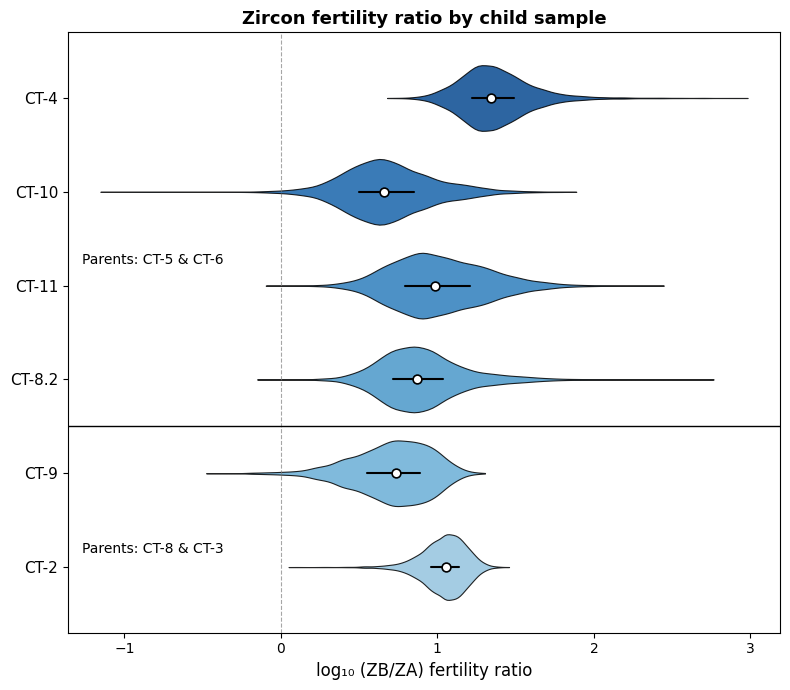

In [10]:
def zfertility_violin(results_list, labels, title, separator_after=None,
                     group_labels=None, save_path=None, figsize=(8, 7)):
    """Horizontal violin plot of log10 ZB/ZA distributions."""
    data = [r['ZB_ZA']['log10_samples'] for r in results_list]
    n = len(labels)
    cmap = plt.cm.Blues
    colors = [cmap(0.4 + 0.5*i/max(n-1,1)) for i in range(n)]
    
    fig, ax = plt.subplots(figsize=figsize)
    parts = ax.violinplot(data, positions=range(1, n+1), vert=False,
                          widths=0.7, showmeans=False, showextrema=False, showmedians=False)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i]); pc.set_edgecolor('black')
        pc.set_linewidth(0.8); pc.set_alpha(0.85)
    
    for i, (d, pos) in enumerate(zip(data, range(1, n+1))):
        ax.plot([np.percentile(d,25), np.percentile(d,75)], [pos, pos],
                color='black', linewidth=1.5, solid_capstyle='round', zorder=5)
        ax.scatter(np.median(d), pos, color='white', s=40,
                   edgecolor='black', linewidth=1.2, zorder=6)
    
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    if separator_after:
        ax.axhline(separator_after + 0.5, color='black', linewidth=1.0)
    if group_labels:
        for txt, y in group_labels:
            ax.text(0.02, y, txt, transform=ax.transAxes, fontsize=10, va='center')
    
    ax.set_yticks(range(1, n+1)); ax.set_yticklabels(labels, fontsize=11)
    ax.set_ylim(0.3, n+0.7)
    ax.set_xlabel('log₁₀ (ZB/ZA) fertility ratio', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', labelsize=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig, ax

# Combined plot — reversed order so CT-4 is at top
all_results = [zr_ct2, zr_ct9, zr_ct82, zr_ct11, zr_ct10, zr_ct4]
all_labels  = ['CT-2','CT-9','CT-8.2','CT-11','CT-10','CT-4']

fig, ax = zfertility_violin(
    all_results, all_labels,
    title='Zircon fertility ratio by child sample',
    separator_after=2,
    group_labels=[('Parents: CT-8 & CT-3', 0.14), ('Parents: CT-5 & CT-6', 0.62)],
    save_path='Figures/violin_zfertility_combined.png'
)
plt.show()

## 11. Flux-ordered erosion rate summary

In [11]:
print("Flux-ordered erosion rates (external uncertainty, median ± std)")
print(f"{'Sample':<30} {'Median':>8} {'Std':>8}")
print("-"*50)
for label, arr in [
    ('CT-5 (ordered vs CT-7)',       CT5_res),
    ('CT-6 (ordered vs CT-1)',       CT6_res),
    ('CT-5 → CT-10 scenario',        CT5_10),
    ('CT-6 → CT-10 scenario',        CT6_10),
    ('CT-10',                        CT10_f),
    ('CT-5 → CT-11 scenario',        CT5_11),
    ('CT-6 → CT-11 scenario',        CT6_11),
    ('CT-11',                        CT11_f),
    ('CT-5 → CT-8 scenario',         CT5_8),
    ('CT-6 → CT-8 scenario',         CT6_8),
    ('CT-8 (via CT-5+CT-6)',         CT8_f),
    ('CT-8 (ordered vs CT-4)',       CT8_res),
    ('CT-3 (independent)',           CT3_res),
]:
    print(f"{label:<30} {np.median(arr):>8.2f} {np.std(arr):>8.2f}")

Flux-ordered erosion rates (external uncertainty, median ± std)
Sample                           Median      Std
--------------------------------------------------
CT-5 (ordered vs CT-7)           413.24    27.24
CT-6 (ordered vs CT-1)            29.79     2.45
CT-5 → CT-10 scenario            413.24    27.24
CT-6 → CT-10 scenario             29.79     2.45
CT-10                            246.08    21.40
CT-5 → CT-11 scenario            413.24    27.24
CT-6 → CT-11 scenario             29.79     2.45
CT-11                            286.17    24.51
CT-5 → CT-8 scenario             413.24    27.24
CT-6 → CT-8 scenario              29.79     2.45
CT-8 (via CT-5+CT-6)             262.95    22.89
CT-8 (ordered vs CT-4)           262.92    22.76
CT-3 (independent)                29.50     2.42


## 12. Results summary

In [12]:
print("="*90)
print("SUMMARY: Quartz and Zircon Fertility Ratios (external uncertainty)")
print("="*90)
print(f"{'Scenario':<25} {'Q Qb/Qa med':>12} {'Q IQR':>16} {'Z ZB/ZA med':>12} {'Z IQR':>16}")
print("-"*90)

qtz = [(Q_ct4, 'CT-6/CT-5→CT-4'), (Q_ct10,'CT-6/CT-5→CT-10'),
       (Q_ct11,'CT-6/CT-5→CT-11'),(Q_ct82,'CT-6/CT-5→CT-8.2'),
       (Q_ct9, 'CT-3/CT-8→CT-9'), (Q_ct2, 'CT-3/CT-8→CT-2')]
zrc = [zr_ct4, zr_ct10, zr_ct11, zr_ct82, zr_ct9, zr_ct2]

for (Q, label), zr in zip(qtz, zrc):
    q25,q50,q75 = np.percentile(Q,[25,50,75])
    r = zr['ZB_ZA']
    print(f"{label:<25} {q50:>12.3f} ({q25:.3f}-{q75:.3f})    {r['median']:>8.3f} ({r['p25']:.3f}-{r['p75']:.3f})")

SUMMARY: Quartz and Zircon Fertility Ratios (external uncertainty)
Scenario                   Q Qb/Qa med            Q IQR  Z ZB/ZA med            Z IQR
------------------------------------------------------------------------------------------
CT-6/CT-5→CT-4                  79.485 (46.986-164.647)      22.131 (16.612-30.870)
CT-6/CT-5→CT-10                  0.285 (0.207-0.372)       4.572 (3.136-7.122)
CT-6/CT-5→CT-11                  0.134 (0.076-0.202)       9.595 (6.225-16.226)
CT-6/CT-5→CT-8.2                 0.207 (0.137-0.287)       7.409 (5.239-10.939)
CT-3/CT-8→CT-9                  33.880 (26.636-43.903)       5.412 (3.569-7.789)
CT-3/CT-8→CT-2                  90.781 (68.683-126.665)      11.337 (9.056-13.727)
